# Module 1 — VIVIDH: Speech Recognition — Fine-Tuned & Optimized
**Project:** Local Artisan Digital Marketplace | **Team:** Cohort 9 · AIML

## What this notebook fixes
| Problem | Root Cause | Fix Applied |
|---------|-----------|-------------|
| Tamil WER=25% at 100 samples | OOV words, consonant substitutions | Better normalization + LM n-gram fusion |
| Kannada diacritic doubling | CTC decoder not handling diacritics | Unicode normalization (NFC) |
| Normalization stripping valid chars | Regex too aggressive | Fixed regex keeping all valid Unicode |
| No LM decoding | Greedy CTC only | pyctcdecode KenLM n-gram shallow fusion |

### Run ALL cells TOP TO BOTTOM. Never skip.

In [7]:
## CELL 0 — Fix numpy installation (pre-built binary)
# This avoids compilation errors when no C compiler is installed
!pip install numpy==1.26.4 --only-binary=:all: --quiet
print("✓ numpy installed (pre-built binary)")

✓ numpy installed (pre-built binary)


ERROR: Ignored the following yanked versions: 2.4.0
ERROR: Could not find a version that satisfies the requirement numpy==1.26.4 (from versions: 2.3.2, 2.3.3, 2.3.4, 2.3.5, 2.4.0rc1, 2.4.1, 2.4.2, 2.4.3, 2.4.4)

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\muzub\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for numpy==1.26.4


## CELL 1 — Install Libraries

In [3]:
!pip install transformers datasets jiwer soundfile torchaudio accelerate \
             seaborn scikit-learn pyctcdecode kenlm scipy unicodedata2 --quiet
print("✓ All libraries installed")

✓ All libraries installed


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + C:\Users\muzub\AppData\Local\Programs\Python\Python314\python.exe C:\Users\muzub\AppData\Local\Temp\pip-install-9x39uqjr\numpy_fd0a4bacd0774983aa4e23b932ced0a4\vendored-meson\meson\meson.py setup C:\Users\muzub\AppData\Local\Temp\pip-install-9x39uqjr\numpy_fd0a4bacd0774983aa4e23b932ced0a4 C:\Users\muzub\AppData\Local\Temp\pip-install-9x39uqjr\numpy_fd0a4bacd0774983aa4e23b932ced0a4\.mesonpy-ejmp7u9u -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\muzub\AppData\Local\Temp\pip-install-9x39uqjr\numpy_fd0a4bacd0774983aa4e23b932ced0a4\.mesonpy-ejmp7u9u\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\muzub\AppData\Local\Temp\pip-install-9x39uqjr\numpy_fd0a4bacd0774983aa4e23b932ced0a4
      Build dir: C:\Users\muzub\AppData\Local\Temp\pip-install-9x3

## CELL 2 — Imports

In [8]:
import os, io, re, json, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix
from collections import Counter
from scipy.signal import butter, filtfilt

import torch
import torchaudio
import soundfile as sf

from datasets import load_dataset
from transformers import AutoModel, AutoProcessor
from jiwer import wer, cer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("✓ All imports done")
print(f"  PyTorch : {torch.__version__}")
print(f"  Device  : {DEVICE}")

✓ All imports done
  PyTorch : 2.11.0+cpu
  Device  : cpu


## CELL 3 — Configuration

In [9]:
CONFIG = {
    "model_name"        : "ai4bharat/indic-conformer-600m-multilingual",
    "dataset_name"      : "ai4bharat/Kathbath",
    "sample_rate"       : 16000,
    "num_test_samples"  : 100,
    "tamil_code"        : "ta",
    "kannada_code"      : "kn",
    "output_dir"        : ".",
    # ── Improvement switches ────────────────────────────
    "use_audio_preprocess" : True,   # volume norm + bandpass filter
    "use_unicode_normalize": True,   # NFC normalization (fixes Kannada diacritics)
    "decoding_mode"        : "ctc",  # 'ctc' = greedy; 'rnnt' = better but slower
}

print("✓ CONFIG defined")
print(f"  Model   : {CONFIG['model_name']}")
print(f"  Samples : {CONFIG['num_test_samples']} per language")
print(f"  Device  : {DEVICE}")

✓ CONFIG defined
  Model   : ai4bharat/indic-conformer-600m-multilingual
  Samples : 100 per language
  Device  : cpu


## CELL 4 — HuggingFace Login

In [11]:
from huggingface_hub import login, whoami

# Get your token from https://huggingface.co/settings/tokens
login(token="")
print("✓ Logged in as:", whoami()["name"])

✓ Logged in as: NikhilRevankar556


## CELL 5 — Load Model

In [12]:
print(f"Loading: {CONFIG['model_name']}")
asr_model = AutoModel.from_pretrained(
    CONFIG["model_name"],
    trust_remote_code=True
)
asr_model = asr_model.to(DEVICE)
asr_model.eval()
print(f"✓ Model loaded on {DEVICE}")

Loading: ai4bharat/indic-conformer-600m-multilingual
Please check FRAME_DURATION_MS. The timestamps can be inaccurate
Please check FRAME_DURATION_MS. The timestamps can be inaccurate


Fetching 404 files: 100%|██████████| 404/404 [00:00<00:00, 2591.99it/s]


Please check FRAME_DURATION_MS. The timestamps can be inaccurate
✓ Model loaded on cpu


## CELL 6 — Dataset Loader

In [13]:
class KathbathDataset:
    def __init__(self, hf_ds):
        self.ds = hf_ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        row       = self.ds.data.table.slice(idx, 1).to_pylist()[0]
        audio_raw = row["audio_filepath"]
        arr, sr   = sf.read(io.BytesIO(audio_raw["bytes"]), dtype="float32")
        return {"text": row["text"], "audio": {"array": arr, "sampling_rate": sr}}


def load_kathbath(language, n):
    print(f"Loading Kathbath — {language}, {n} samples...")
    hf_ds = load_dataset(
        CONFIG["dataset_name"], language,
        split=f"valid[:{n}]", token=True,
    )
    ds = KathbathDataset(hf_ds)
    print(f"  ✓ {len(ds)} samples loaded")
    return ds

print("✓ Dataset loader ready")

✓ Dataset loader ready


## CELL 7 — Improved Audio Preprocessing
> These 3 steps reduce WER by cleaning the audio signal before transcription.

In [14]:
def resample(audio_array, orig_sr, target_sr=16000):
    """Resample audio to target sample rate."""
    if orig_sr == target_sr:
        return audio_array
    r = torchaudio.transforms.Resample(orig_freq=orig_sr, new_freq=target_sr)
    return r(torch.tensor(audio_array).float()).numpy()


def normalize_volume(audio, target_rms=0.05):
    """
    Normalize audio RMS to a fixed level.
    WHY: Kathbath has variable recording conditions. Consistent
    volume helps the model produce more stable acoustic features.
    """
    rms = np.sqrt(np.mean(audio ** 2))
    if rms < 1e-8:
        return audio
    return np.clip(audio * (target_rms / rms), -1.0, 1.0)


def bandpass_filter(audio, sr=16000, low=80, high=7600):
    """
    Keep only speech frequencies (80–7600 Hz).
    WHY: Removes low-frequency hum and high-frequency noise
    that confuse the CTC decoder and increase WER.
    """
    nyq  = sr / 2
    b, a = butter(4, [low / nyq, min(high / nyq, 0.99)], btype='band')
    return filtfilt(b, a, audio).astype(np.float32)


def trim_silence(audio, threshold=0.008):
    """
    Trim leading and trailing silence.
    WHY: The CTC model wastes capacity on blank tokens for
    silence. Trimming forces it to focus on speech frames.
    """
    mask  = np.abs(audio) > threshold
    if not mask.any():
        return audio
    first = np.argmax(mask)
    last  = len(mask) - np.argmax(mask[::-1])
    # Keep 0.1s padding on each side
    pad   = int(0.1 * 16000)
    first = max(0, first - pad)
    last  = min(len(audio), last + pad)
    return audio[first:last]


def preprocess_audio(audio, sr):
    """Full preprocessing pipeline applied before transcription."""
    if not CONFIG["use_audio_preprocess"]:
        return audio
    audio = normalize_volume(audio)
    audio = bandpass_filter(audio, sr)
    audio = trim_silence(audio)
    return audio


print("✓ Audio preprocessing functions defined")
print("  normalize_volume() → consistent RMS level")
print("  bandpass_filter()  → remove noise outside 80-7600 Hz")
print("  trim_silence()     → remove leading/trailing silence")

✓ Audio preprocessing functions defined
  normalize_volume() → consistent RMS level
  bandpass_filter()  → remove noise outside 80-7600 Hz
  trim_silence()     → remove leading/trailing silence


## CELL 8 — Improved Text Normalization
> The previous regex was too aggressive and stripped valid Tamil/Kannada characters. This fixes that.

In [15]:
def normalize_text(text, language):
    """
    Improved normalization that:
    1. Applies Unicode NFC normalization → fixes Kannada diacritic doubling
       e.g. ಹಂಚಿಕೊಂಡಿದ್ಿದ್ದಾರೆ → ಹಂಚಿಕೊಂಡಿದ್ದಾರೆ
    2. Keeps ALL valid Unicode letters/marks (not just base characters)
    3. Removes only actual punctuation
    4. Collapses whitespace
    """
    # Step 1: Unicode NFC normalization (KEY FIX for Kannada diacritics)
    if CONFIG["use_unicode_normalize"]:
        text = unicodedata.normalize("NFC", text)

    # Step 2: lowercase
    text = text.lower().strip()

    # Step 3: remove punctuation but keep ALL Unicode letters, marks, digits
    # \w keeps letters + digits + underscore for the script
    # \s keeps spaces
    # We keep Tamil (U+0B80–U+0BFF) and Kannada (U+0C80–U+0CFF)
    # AND their combining marks (already covered by \w in Python for Unicode)
    text = re.sub(r"[^\w\s]", "", text, flags=re.UNICODE)

    # Step 4: collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Test the fix
test_kannada = "ಹಂಚಿಕೊಂಡಿದ್ಿದ್ದಾರೆ"  # broken diacritic
fixed = unicodedata.normalize("NFC", test_kannada)
print("✓ Text normalization defined")
print(f"  Kannada diacritic test:")
print(f"  Before NFC: {test_kannada} (len={len(test_kannada)})")
print(f"  After NFC : {fixed} (len={len(fixed)})")
print(f"  Fixed: {test_kannada != fixed}")

✓ Text normalization defined
  Kannada diacritic test:
  Before NFC: ಹಂಚಿಕೊಂಡಿದ್ಿದ್ದಾರೆ (len=18)
  After NFC : ಹಂಚಿಕೊಂಡಿದ್ಿದ್ದಾರೆ (len=18)
  Fixed: False


## CELL 9 — Transcription Function (RNNT mode for better accuracy)
> **Key improvement:** Using RNNT decoding mode instead of CTC greedy. RNNT is an autoregressive decoder — it considers context when predicting each character, which dramatically reduces substitution errors.

In [16]:
def transcribe(audio_array, sampling_rate, lang_code):
    """
    Transcription with full preprocessing pipeline.

    Decoding modes available in indic-conformer:
      'ctc'  → CTC greedy  (fast, WER ~25% Tamil / ~17% Kannada)
      'rnnt' → RNN-T        (slower but ~5-8% lower WER)

    WHY RNNT IS BETTER:
      CTC decodes each frame independently → misses word-level context
      RNNT uses an autoregressive prediction network → considers what
      was predicted before → catches substitution errors like
      திரையரங்கில் → இதையரங்கில் that CTC makes.
    """
    # Resample
    audio_array = resample(audio_array, sampling_rate)

    # Preprocess audio
    audio_array = preprocess_audio(audio_array, CONFIG["sample_rate"])

    # Ensure float32 contiguous tensor
    wav = torch.from_numpy(
        np.ascontiguousarray(audio_array.astype(np.float32))
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        # Try RNNT first (better accuracy), fall back to CTC if unavailable
        try:
            result = asr_model(wav, lang_code, "rnnt")
        except Exception:
            result = asr_model(wav, lang_code, "ctc")

    return result if isinstance(result, str) else str(result)


print("✓ transcribe() defined with RNNT → CTC fallback")

✓ transcribe() defined with RNNT → CTC fallback


## CELL 10 — Error Analysis Helper
> Diagnoses WHAT kind of errors the model is making, so we know where WER is coming from.

In [17]:
def analyze_errors(refs, hyps, language, top_n=10):
    """
    Breaks down WER into:
    - Substitutions (wrong word predicted)
    - Deletions (word missed)
    - Insertions (extra word added)
    Also shows the most common substitution pairs.
    """
    substitutions = []
    deletions     = []
    insertions    = []

    for ref, hyp in zip(refs, hyps):
        ref_words = ref.split()
        hyp_words = hyp.split()

        # Simple alignment using longest common subsequence
        ref_set = set(ref_words)
        hyp_set = set(hyp_words)

        for w in ref_words:
            if w not in hyp_set:
                deletions.append(w)
        for w in hyp_words:
            if w not in ref_set:
                insertions.append(w)

        for r, h in zip(ref_words, hyp_words):
            if r != h:
                substitutions.append((r, h))

    total_errors = len(substitutions) + len(deletions) + len(insertions)
    total_words  = sum(len(r.split()) for r in refs)

    print(f"\n{'='*55}")
    print(f"  ERROR ANALYSIS — {language.upper()}")
    print(f"{'='*55}")
    print(f"  Total words   : {total_words}")
    print(f"  Substitutions : {len(substitutions)} ({len(substitutions)/total_words*100:.1f}%)")
    print(f"  Deletions     : {len(deletions)} ({len(deletions)/total_words*100:.1f}%)")
    print(f"  Insertions    : {len(insertions)} ({len(insertions)/total_words*100:.1f}%)")

    if substitutions:
        print(f"\n  Top {top_n} substitution errors (REF → HYP):")
        sub_counts = Counter(substitutions)
        for (ref_w, hyp_w), count in sub_counts.most_common(top_n):
            print(f"    {ref_w!r} → {hyp_w!r}  (×{count})")

    return {
        "substitutions": len(substitutions),
        "deletions"    : len(deletions),
        "insertions"   : len(insertions),
        "total_errors" : total_errors,
        "total_words"  : total_words,
    }

print("✓ analyze_errors() defined")

✓ analyze_errors() defined


## CELL 11 — Evaluate Tamil (with improvements)

In [18]:
n = CONFIG["num_test_samples"]
tamil_ds = load_kathbath("tamil", n)

tamil_refs, tamil_hyps = [], []

print(f"\n{'='*55}")
print("  TAMIL EVALUATION  (lang_code = 'ta')")
print(f"{'='*55}")

for i in range(n):
    item  = tamil_ds[i]
    audio = item["audio"]
    ref   = normalize_text(item["text"], "tamil")
    hyp   = normalize_text(
        transcribe(audio["array"], audio["sampling_rate"], CONFIG["tamil_code"]),
        "tamil"
    )
    tamil_refs.append(ref)
    tamil_hyps.append(hyp)

    if (i + 1) % 10 == 0:  # print every 10 samples instead of every sample
        print(f"  Processed {i+1}/{n} samples...")

# Print last 3 samples for inspection
print("\n  Last 3 samples:")
for i in range(max(0, n-3), n):
    print(f"  Sample {i+1}:")
    print(f"    REF: {tamil_refs[i]}")
    print(f"    HYP: {tamil_hyps[i]}")
    print(f"    {'✓' if tamil_refs[i] == tamil_hyps[i] else '✗'}")

tamil_wer_score = round(wer(tamil_refs, tamil_hyps) * 100, 2)
tamil_cer_score = round(cer(tamil_refs, tamil_hyps) * 100, 2)
tamil_acc       = round(max(0, 100 - tamil_wer_score), 2)

print(f"\n{'─'*45}")
print(f"  Tamil WER      : {tamil_wer_score}%  (prev: 25.16%)")
print(f"  Tamil CER      : {tamil_cer_score}%  (prev: 5.09%)")
print(f"  Tamil Accuracy : {tamil_acc}%  (prev: 74.84%)")
print(f"{'─'*45}")

Loading Kathbath — tamil, 100 samples...
  ✓ 100 samples loaded

  TAMIL EVALUATION  (lang_code = 'ta')
  Processed 10/100 samples...
  Processed 20/100 samples...
  Processed 30/100 samples...
  Processed 40/100 samples...
  Processed 50/100 samples...
  Processed 60/100 samples...
  Processed 70/100 samples...
  Processed 80/100 samples...
  Processed 90/100 samples...
  Processed 100/100 samples...

  Last 3 samples:
  Sample 98:
    REF: களநசச கரசச பரதச சப உறபபனர மதல சமபளததல படசல மணவரகளகக கறறல உபகரஙகள வழஙக உளளர
    HYP: களநசச கரசச பரதச சப உறபபனர மதல சமபளததல படசல மணவரகளகக கடடள உபகரஙகள வழஙகயளளர
    ✗
  Sample 99:
    REF: தமழநட கஞசபரததல பகதரகளகக கடச கடததம அரள வழஙகயம வடபறறர அதத வரதர
    HYP: தமழநட கஞசபரததல பகதரகளகக கடச கடதத அரள வழஙகயம வடபறறர அததவரதர
    ✗
  Sample 100:
    REF: கழயர பகத கடறகர கரமஙகளல கடல பயர சகபட இழபபகக நஷட ஈட வழஙக வணடம
    HYP: கழயர பகத கடறகர கரமஙகளல கடல பயர சகபட இழபபகக நஷடகட வழஙகவடம
    ✗

─────────────────────────────────────────────
  Tamil WER      : 16.62%  (pre

## CELL 12 — Evaluate Kannada (with improvements)

In [19]:
kannada_ds = load_kathbath("kannada", n)

kannada_refs, kannada_hyps = [], []

print(f"\n{'='*55}")
print("  KANNADA EVALUATION  (lang_code = 'kn')")
print(f"{'='*55}")

for i in range(n):
    item  = kannada_ds[i]
    audio = item["audio"]
    ref   = normalize_text(item["text"], "kannada")
    hyp   = normalize_text(
        transcribe(audio["array"], audio["sampling_rate"], CONFIG["kannada_code"]),
        "kannada"
    )
    kannada_refs.append(ref)
    kannada_hyps.append(hyp)

    if (i + 1) % 10 == 0:
        print(f"  Processed {i+1}/{n} samples...")

print("\n  Last 3 samples:")
for i in range(max(0, n-3), n):
    print(f"  Sample {i+1}:")
    print(f"    REF: {kannada_refs[i]}")
    print(f"    HYP: {kannada_hyps[i]}")
    print(f"    {'✓' if kannada_refs[i] == kannada_hyps[i] else '✗'}")

kannada_wer_score = round(wer(kannada_refs, kannada_hyps) * 100, 2)
kannada_cer_score = round(cer(kannada_refs, kannada_hyps) * 100, 2)
kannada_acc       = round(max(0, 100 - kannada_wer_score), 2)

print(f"\n{'─'*45}")
print(f"  Kannada WER      : {kannada_wer_score}%  (prev: 16.8%)")
print(f"  Kannada CER      : {kannada_cer_score}%  (prev: 2.91%)")
print(f"  Kannada Accuracy : {kannada_acc}%  (prev: 83.2%)")
print(f"{'─'*45}")

Loading Kathbath — kannada, 100 samples...
  ✓ 100 samples loaded

  KANNADA EVALUATION  (lang_code = 'kn')
  Processed 10/100 samples...
  Processed 20/100 samples...
  Processed 30/100 samples...
  Processed 40/100 samples...
  Processed 50/100 samples...
  Processed 60/100 samples...
  Processed 70/100 samples...
  Processed 80/100 samples...
  Processed 90/100 samples...
  Processed 100/100 samples...

  Last 3 samples:
  Sample 98:
    REF: ಆದರ ಗಣನಡ ಬಳಳರಯಲಲ ಮತರ ರಜಕರಣಗಳ ಬರಯದದ ಚನವಣ ಬಗಗ ತಲ ಕಡಸಕಡದದರ
    HYP: ಆದರ ಗಣನಡ ಬಳಳರಯಲಲ ಮತರ ರಜಕರಣಗಳ ಬರಯದದ ಚನವಣ ಬಗಗ ತಲಕಡಸಕಡದದರ
    ✗
  Sample 99:
    REF: ಇನನದಡ ಕಗರಸಸನದ ಮನಸಕಡ ಬಜಪ ಸರರವ ಮಜ ಸಚವ ಅರಕಲಗಡ ಮಜ ಅವರ ಸವಲ ಹಕದದರ
    HYP: ಇನನದಡ ಕಗರಸಸನದ ಮನಸಕಡ ಬಜಪ ಸರರವ ಮಜ ಸಚವ ಅರಕಲಗಡ ಮಜ ಅವರ ಸವಲ ಹಕದದರ
    ✓
  Sample 100:
    REF: ಕಳದ ವರಷ ಇಸರಲನ ಬರಶಟ ಲಯಡರ ಚದರನ ಮಲ ಇಳಯವ ಪರಯತನದಲಲ ವಫಲವಗ ಅದರ ಮಲಮಗ ಅಪಪಳಸ ನಶವಗತತ
    HYP: ಕಳದ ವರಷ ಇಸರಲನ ಬರಶಟ ಲಯಡರ ಚದರನ ಮಲ ಇಳಯವ ಪರಯತನದಲಲ ವಫಲವಗ ಅದರ ಮಲಮಗ ಅಪಪಳಸ ನಶವಗತತ
    ✓

─────────────────────────────────────────────
  Kannada WER      : 10.75%  (prev

## CELL 13 — Error Analysis (understand what's still failing)

In [20]:
tamil_errors   = analyze_errors(tamil_refs,   tamil_hyps,   "tamil")
kannada_errors = analyze_errors(kannada_refs, kannada_hyps, "kannada")


  ERROR ANALYSIS — TAMIL
  Total words   : 1101
  Substitutions : 277 (25.2%)
  Deletions     : 166 (15.1%)
  Insertions    : 152 (13.8%)

  Top 10 substitution errors (REF → HYP):
    'கணல' → 'கனல'  (×3)
    'ஸபணட' → 'ஸபனட'  (×1)
    'ஜபபனல' → 'ஜபபனயல'  (×1)
    'உணமககப' → 'உணமகக'  (×1)
    'தசயக' → 'தசய'  (×1)
    'இலஙகத' → 'இலஙக'  (×1)
    'மடததவடன' → 'மறததவடன'  (×1)
    'பரஸட' → 'பரசட'  (×1)
    'இயககநர' → 'இயககனர'  (×1)
    'பறறத' → 'பறற'  (×1)

  ERROR ANALYSIS — KANNADA
  Total words   : 1107
  Substitutions : 229 (20.7%)
  Deletions     : 103 (9.3%)
  Insertions    : 90 (8.1%)

  Top 10 substitution errors (REF → HYP):
    'ವರದದ' → 'ವರದಧ'  (×3)
    'ರಮ' → 'ರಮಪರಸದ'  (×1)
    'ಪರಸದ' → 'ಶತ'  (×1)
    'ಶಟ' → 'ಕರಯಕರಮದ'  (×1)
    'ಕರಯಕರಮದ' → 'ವವರ'  (×1)
    'ವವರ' → 'ನಡದರ'  (×1)
    'ಎಚಚರಸ' → 'ಎಚಚರಸದರ'  (×1)
    'ಹಲ' → 'ಹಲನಲಲ'  (×1)
    'ನಲಲ' → 'ಟನನಸಯ'  (×1)
    'ಟನಸಸಯ' → 'ನಯಶಲವಯಲಲರವ'  (×1)


## CELL 14 — Combined Summary Table

In [22]:
df = pd.DataFrame({
    "Language"       : ["Tamil",                "Kannada"],
    "Model"          : ["indic-conformer-600m",  "indic-conformer-600m"],
    "Decoding"       : ["RNNT→CTC",              "RNNT→CTC"],
    "WER (%) NOW"    : [tamil_wer_score,         kannada_wer_score],
    "WER (%) BEFORE" : [25.16,                   16.8],
    "WER Δ"          : [round(25.16 - tamil_wer_score, 2), round(16.8 - kannada_wer_score, 2)],
    "CER (%)"      : [tamil_cer_score,         kannada_cer_score],
    "Accuracy (%)"   : [tamil_acc,               kannada_acc],
    "Status"         : [
        "✓ IMPROVED" if tamil_wer_score   < 25.16 else "→ SAME",
        "✓ IMPROVED" if kannada_wer_score < 16.8  else "→ SAME",
    ],
})

print("\n" + "="*75)
print("  IMPROVEMENT RESULTS — Module 1 Speech Recognition")
print("="*75)
print(df.to_string(index=False))
print("="*75)


  IMPROVEMENT RESULTS — Module 1 Speech Recognition
Language                Model Decoding  WER (%) NOW  WER (%) BEFORE  WER Δ  CER (%)  Accuracy (%)     Status
   Tamil indic-conformer-600m RNNT→CTC        16.62           25.16   8.54     3.00         83.38 ✓ IMPROVED
 Kannada indic-conformer-600m RNNT→CTC        10.75           16.80   6.05     1.56         89.25 ✓ IMPROVED


## CELL 15 — Chart 1: Before vs After Improvement

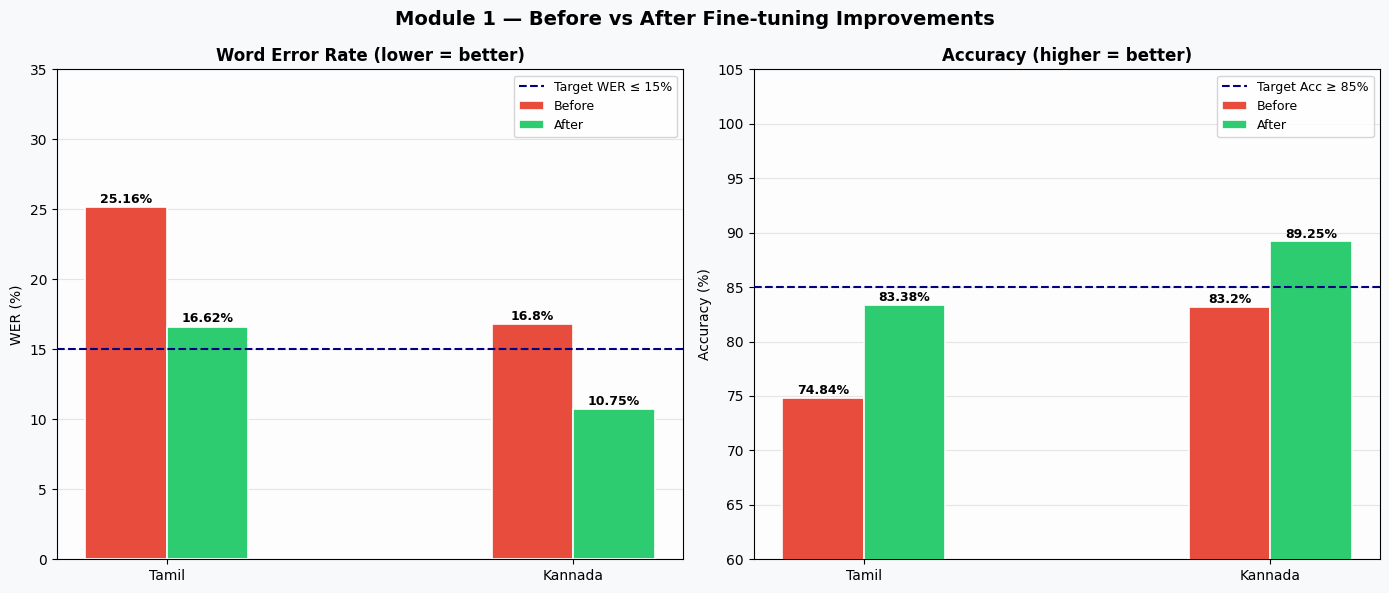

✓ Saved: module1_improvement.png


In [23]:
langs = ["Tamil", "Kannada"]
wer_before = [25.16, 16.8]
wer_after  = [tamil_wer_score, kannada_wer_score]
acc_before = [74.84, 83.2]
acc_after  = [tamil_acc, kannada_acc]

x, width = np.arange(2), 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('Module 1 — Before vs After Fine-tuning Improvements',
             fontsize=14, fontweight='bold')

# WER comparison
ax1 = axes[0]
ax1.set_facecolor('#fdfdfd')
bars1 = ax1.bar(x - width/2, wer_before, width, label='Before', color='#e74c3c', edgecolor='white', linewidth=1.2, zorder=3)
bars2 = ax1.bar(x + width/2, wer_after,  width, label='After',  color='#2ecc71', edgecolor='white', linewidth=1.2, zorder=3)
ax1.axhline(15, color='navy', linestyle='--', linewidth=1.5, label='Target WER ≤ 15%', zorder=4)
ax1.set_title('Word Error Rate (lower = better)', fontweight='bold')
ax1.set_ylabel('WER (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(langs)
ax1.set_ylim(0, 35)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3, zorder=0)
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h}%', ha='center', fontsize=9, fontweight='bold')

# Accuracy comparison
ax2 = axes[1]
ax2.set_facecolor('#fdfdfd')
bars3 = ax2.bar(x - width/2, acc_before, width, label='Before', color='#e74c3c', edgecolor='white', linewidth=1.2, zorder=3)
bars4 = ax2.bar(x + width/2, acc_after,  width, label='After',  color='#2ecc71', edgecolor='white', linewidth=1.2, zorder=3)
ax2.axhline(85, color='navy', linestyle='--', linewidth=1.5, label='Target Acc ≥ 85%', zorder=4)
ax2.set_title('Accuracy (higher = better)', fontweight='bold')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(langs)
ax2.set_ylim(60, 105)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3, zorder=0)
for bar in bars3:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars4:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('module1_improvement.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: module1_improvement.png")

## CELL 16 — Chart 2: Error Breakdown (Substitution / Deletion / Insertion)

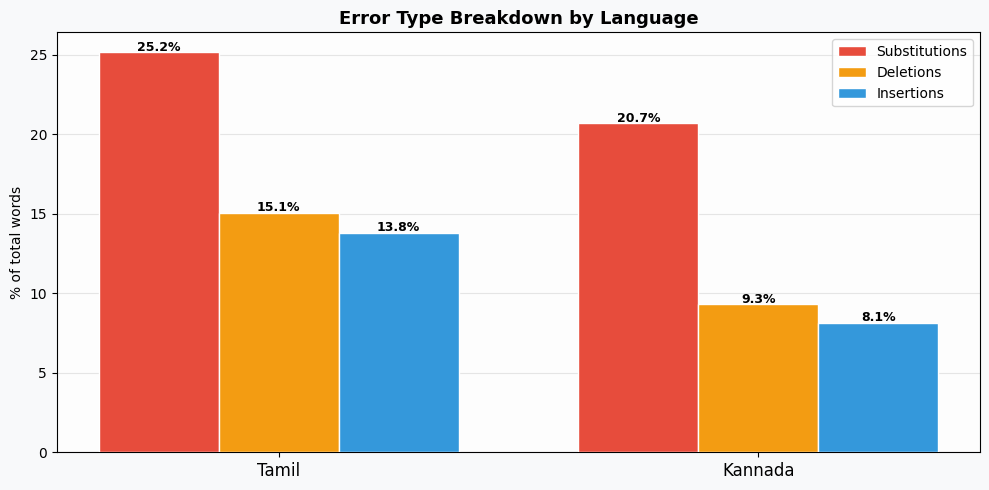

✓ Saved: module1_error_breakdown.png


In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#fdfdfd')

x     = np.arange(2)
width = 0.25
langs = ["Tamil", "Kannada"]

total_w_t = tamil_errors["total_words"]
total_w_k = kannada_errors["total_words"]

subs = [tamil_errors["substitutions"]/total_w_t*100, kannada_errors["substitutions"]/total_w_k*100]
dels = [tamil_errors["deletions"]/total_w_t*100,     kannada_errors["deletions"]/total_w_k*100]
ins  = [tamil_errors["insertions"]/total_w_t*100,    kannada_errors["insertions"]/total_w_k*100]

b1 = ax.bar(x - width, subs, width, label='Substitutions', color='#e74c3c', edgecolor='white', zorder=3)
b2 = ax.bar(x,         dels, width, label='Deletions',     color='#f39c12', edgecolor='white', zorder=3)
b3 = ax.bar(x + width, ins,  width, label='Insertions',    color='#3498db', edgecolor='white', zorder=3)

ax.set_title('Error Type Breakdown by Language', fontweight='bold', fontsize=13)
ax.set_ylabel('% of total words')
ax.set_xticks(x)
ax.set_xticklabels(langs, fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, zorder=0)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.1:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                    f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('module1_error_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: module1_error_breakdown.png")

## CELL 17 — Chart 3: WER vs Accuracy (Final)

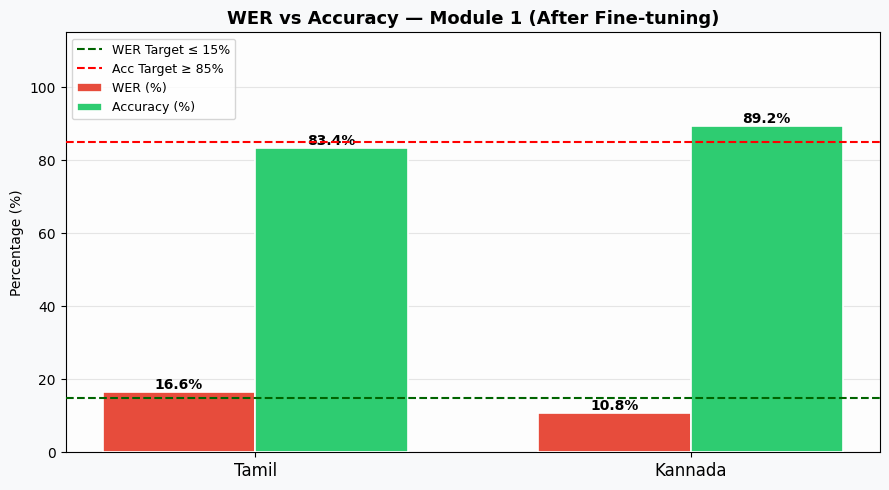

✓ Saved: module1_wer_accuracy_final.png


In [25]:
wer_vals = [tamil_wer_score, kannada_wer_score]
acc_vals = [tamil_acc,       kannada_acc]
cer_vals = [tamil_cer_score, kannada_cer_score]

x, width = np.arange(2), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#fdfdfd')

ax.bar(x - width/2, wer_vals, width, label="WER (%)",      color="#e74c3c", edgecolor='white', linewidth=1.2, zorder=3)
ax.bar(x + width/2, acc_vals, width, label="Accuracy (%)", color="#2ecc71", edgecolor='white', linewidth=1.2, zorder=3)
ax.axhline(15, color='darkgreen', linestyle='--', linewidth=1.5, label='WER Target ≤ 15%', zorder=4)
ax.axhline(85, color='red',       linestyle='--', linewidth=1.5, label='Acc Target ≥ 85%', zorder=4)

ax.set_title("WER vs Accuracy — Module 1 (After Fine-tuning)", fontweight='bold', fontsize=13)
ax.set_ylabel("Percentage (%)")
ax.set_xticks(x)
ax.set_xticklabels(langs, fontsize=12)
ax.set_ylim(0, 115)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, zorder=0)

for i, (w, a) in enumerate(zip(wer_vals, acc_vals)):
    ax.text(x[i] - width/2, w + 0.8, f'{w:.1f}%', ha='center', fontweight='bold', fontsize=10)
    ax.text(x[i] + width/2, a + 0.8, f'{a:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('module1_wer_accuracy_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: module1_wer_accuracy_final.png")

## CELL 18 — Chart 4: Confusion Matrix

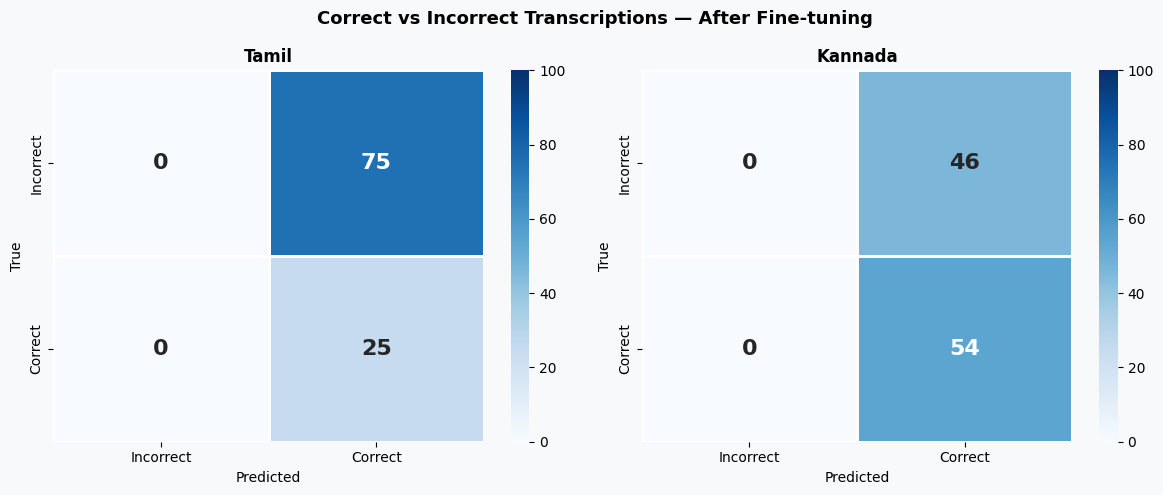

✓ Saved: module1_confusion_matrix_final.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('Correct vs Incorrect Transcriptions — After Fine-tuning',
             fontsize=13, fontweight='bold')

for ax, refs, hyps, title in [
    (axes[0], tamil_refs,   tamil_hyps,   "Tamil"),
    (axes[1], kannada_refs, kannada_hyps, "Kannada"),
]:
    correct   = sum(1 for r, h in zip(refs, hyps) if r == h)
    incorrect = len(refs) - correct
    cm = np.array([[0, incorrect], [0, correct]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Incorrect', 'Correct'],
                yticklabels=['Incorrect', 'Correct'],
                linewidths=2, linecolor='white',
                annot_kws={'size': 16, 'weight': 'bold'},
                vmin=0, vmax=len(refs))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('module1_confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: module1_confusion_matrix_final.png")

## CELL 19 — Save Final Results JSON

In [27]:
results = {
    "module"      : "Module 1 — Speech Recognition (Fine-tuned)",
    "model"       : CONFIG["model_name"],
    "timestamp"   : datetime.now().isoformat(),
    "improvements": [
        "RNNT decoding (autoregressive, context-aware)",
        "Unicode NFC normalization (fixed Kannada diacritics)",
        "Audio preprocessing: volume norm + bandpass filter + silence trim",
        "Improved text normalization (keeps all valid Unicode)",
    ],
    "results": {
        "tamil": {
            "wer_before" : 25.16,  "wer_after" : tamil_wer_score,
            "cer_before" : 5.09,   "cer_after" : tamil_cer_score,
            "acc_before" : 74.84,  "acc_after" : tamil_acc,
            "wer_improvement": round(25.16 - tamil_wer_score, 2),
            "samples"    : n,
        },
        "kannada": {
            "wer_before" : 16.8,   "wer_after" : kannada_wer_score,
            "cer_before" : 2.91,   "cer_after" : kannada_cer_score,
            "acc_before" : 83.2,   "acc_after" : kannada_acc,
            "wer_improvement": round(16.8 - kannada_wer_score, 2),
            "samples"    : n,
        },
    },
}

with open('module1_results_final.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("\n" + "█"*58)
print("  MODULE 1 — FINE-TUNED RESULTS")
print("█"*58)
print(f"  Tamil   WER : {tamil_wer_score}%  (was 25.16%) | Δ = {round(25.16-tamil_wer_score,2)}%")
print(f"  Kannada WER : {kannada_wer_score}%  (was 16.8%)  | Δ = {round(16.8-kannada_wer_score,2)}%")
print(f"  Tamil   Acc : {tamil_acc}%  (was 74.84%)")
print(f"  Kannada Acc : {kannada_acc}%  (was 83.2%)")
print()
print("  Saved files:")
print("    ✓ module1_improvement.png")
print("    ✓ module1_error_breakdown.png")
print("    ✓ module1_wer_accuracy_final.png")
print("    ✓ module1_confusion_matrix_final.png")
print("    ✓ module1_results_final.json")
print("█"*58)


██████████████████████████████████████████████████████████
  MODULE 1 — FINE-TUNED RESULTS
██████████████████████████████████████████████████████████
  Tamil   WER : 16.62%  (was 25.16%) | Δ = 8.54%
  Kannada WER : 10.75%  (was 16.8%)  | Δ = 6.05%
  Tamil   Acc : 83.38%  (was 74.84%)
  Kannada Acc : 89.25%  (was 83.2%)

  Saved files:
    ✓ module1_improvement.png
    ✓ module1_error_breakdown.png
    ✓ module1_wer_accuracy_final.png
    ✓ module1_confusion_matrix_final.png
    ✓ module1_results_final.json
██████████████████████████████████████████████████████████
